In [ ]:
#!pip install langchain langchain-community pypdf2 python-dotenv openai tiktoken

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------------------- ------------------- 1.3/2.5 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 6.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/879.1 kB ? eta -:--:--
   ---------------------------------------- 879.1/879.1 kB 5.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 5.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/542.4 kB ? eta -:--:--
   ---------------------------------------- 542.4/542.4 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.3
    Uninstalling requests-2.32.3:
      Successfully uninstalled requests-2.32.3


In [ ]:
#!pip install langchain langchain-text-splitters

Data Sources

PDF — NIST AI Risk Management Framework (AI RMF 1.0)
This is the perfect Trustworthy AI PDF. It defines seven key trustworthiness characteristics: valid and reliable, safe, secure and resilient, accountable and transparent, explainable and interpretable, privacy-enhanced, and fair with harmful bias managed.
Download directly: https://nvlpubs.nist.gov/nistpubs/ai/nist.ai.100-1.pdf
It is free, official, well-structured with headers and sections — perfect for the chunking lab.

Podcast Transcript — "AI Quick Bits" by Scot Pansing
AI Quick Bits is a podcast about artificial intelligence hosted by Scot Pansing. 
This is ideal because it covers the same Trustworthy AI themes as the NIST PDF (safety, ethics, regulation) and transcripts are freely available as text.
https://aiquickbits.com/interview-with-reid-blackman-ceo-of-virtue-and-author-of-ethical-machines

In [7]:
import sys
!{sys.executable} -m pip install langchain langchain-text-splitters -q

In [8]:
# NEW correct import for langchain >= 0.2
from langchain_text_splitters import CharacterTextSplitter
import matplotlib.pyplot as plt
import numpy as np

In [11]:
import sys
!{sys.executable} -m pip install pdfplumber -q
print("✓ pdfplumber installed")

✓ pdfplumber installed


In [14]:
import pdfplumber
import os

pdf_path = "nist.ai.100-1.pdf"

with pdfplumber.open(pdf_path) as pdf:
    pages_text = []
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            pages_text.append(text)
    pdf_text = "\n".join(pages_text)
    total_pages = len(pdf.pages)

with open("nist_ai_rmf.txt", "w", encoding="utf-8") as f:
    f.write(pdf_text)

print(f"✓ Extracted {len(pdf_text):,} characters")
print(f"  Total pages: {total_pages}")
print(f"  Pages with text: {len(pages_text)}")
print(f"  Saved to: nist_ai_rmf.txt")
print(f"\nPreview (first 300 chars):")
print(pdf_text[:300])

✓ Extracted 101,233 characters
  Total pages: 48
  Pages with text: 48
  Saved to: nist_ai_rmf.txt

Preview (first 300 chars):
NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1.0)
NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1.0)
Thispublicationisavailablefreeofchargefrom:
https://doi.org/10.6028/NIST.AI.100-1
January2023
U.S.DepartmentofCommerce
GinaM.Raimondo,Secretary
Na


In [16]:
import shutil
import os

# Copy audio file to working directory
src  = r"C:\Users\dbyst\Downloads\AIQB-ReidBlackman.mp3"
dst  = os.path.join(os.getcwd(), "AIQB-ReidBlackman.mp3")

shutil.copy2(src, dst)
print(f"✓ Copied to: {dst}")
print(f"  Size: {os.path.getsize(dst)/1024/1024:.1f} MB")

✓ Copied to: c:\Users\dbyst\OneDrive\Desktop\Ironhack_labs\Ironhack_Day10\AIQB-ReidBlackman.mp3
  Size: 39.2 MB


In [19]:
import subprocess
import os

src  = "AIQB-ReidBlackman.mp3"
dst  = "AIQB-ReidBlackman-compressed.mp3"

# Compress to 64kbps mono — reduces size by ~50% with minimal quality loss
subprocess.run([
    "ffmpeg", "-y",
    "-i", src,
    "-b:a", "64k",      # 64kbps bitrate
    "-ac", "1",          # mono (halves file size)
    dst
], capture_output=True)

original_mb   = os.path.getsize(src) / 1024 / 1024
compressed_mb = os.path.getsize(dst) / 1024 / 1024

print(f"Original:   {original_mb:.2f} MB")
print(f"Compressed: {compressed_mb:.2f} MB")
print(f"Reduction:  {(1 - compressed_mb/original_mb)*100:.0f}%")

if compressed_mb < 25:
    print("✓ File is now under 25MB limit — ready to transcribe")
else:
    print("✗ Still too large — will need chunking")

Original:   39.25 MB
Compressed: 19.62 MB
Reduction:  50%
✓ File is now under 25MB limit — ready to transcribe


In [20]:
# ── Transcribe compressed file ────────────────────────────────────
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

print("Transcribing with Whisper — please wait...")

with open("AIQB-ReidBlackman-compressed.mp3", "rb") as f:
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=f,
        response_format="text"
    )

# Save as text file for chunking lab
with open("trustworthy_ai_podcast.txt", "w", encoding="utf-8") as f:
    f.write(transcript)

print(f"✓ Transcribed successfully")
print(f"  Characters: {len(transcript):,}")
print(f"  Words:      {len(transcript.split()):,}")
print(f"  Saved to:   trustworthy_ai_podcast.txt")
print(f"\nPreview (first 300 chars):")
print(transcript[:300])

Transcribing with Whisper — please wait...
✓ Transcribed successfully
  Characters: 44,383
  Words:      8,232
  Saved to:   trustworthy_ai_podcast.txt

Preview (first 300 chars):
Hey everyone, welcome back to AI Quick Bits. I'm your host, Scott Panzing, and in this episode I discuss the world of AI ethics and responsible AI, and ethics in general, with Reid Blackman, founder and CEO of Virtue, an AI ethical risk consultancy. Reid is also the author of the book Ethical Machin


Step 2: Fixed-Size Chunking

In [21]:
# ============================================================
# STEP 2: FIXED-SIZE CHUNKING — PODCAST AND PDF
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os

# ── Load both documents ───────────────────────────────────────────
with open("trustworthy_ai_podcast.txt", "r", encoding="utf-8") as f:
    podcast_text = f.read()

with open("nist_ai_rmf.txt", "r", encoding="utf-8") as f:
    pdf_text = f.read()

print("=" * 55)
print("DOCUMENTS LOADED")
print("=" * 55)
print(f"Podcast text:  {len(podcast_text):,} characters | "
      f"{len(podcast_text.split()):,} words")
print(f"PDF text:      {len(pdf_text):,} characters | "
      f"{len(pdf_text.split()):,} words")
print(f"\nPodcast preview: {podcast_text[:150].strip()}...")
print(f"\nPDF preview:     {pdf_text[:150].strip()}...")


DOCUMENTS LOADED
Podcast text:  44,383 characters | 8,232 words
PDF text:      101,233 characters | 10,656 words

Podcast preview: Hey everyone, welcome back to AI Quick Bits. I'm your host, Scott Panzing, and in this episode I discuss the world of AI ethics and responsible AI, an...

PDF preview:     NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1.0)
NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1...


In [22]:
# ── Chunking functions ────────────────────────────────────────────

def fixed_size_chunk(text, chunk_size, overlap):
    """
    Fixed-size chunking — pure Python, no dependencies.
    Splits text into chunks of chunk_size characters with
    overlap characters shared between consecutive chunks.
    """
    if overlap >= chunk_size:
        raise ValueError("overlap must be smaller than chunk_size")
    chunks = []
    start  = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks


def analyse_chunks(chunks, label):
    """Print statistics and return sizes list."""
    sizes      = [len(c) for c in chunks]
    broken     = sum(1 for c in chunks
                     if not c.strip().endswith(
                         ('.', '!', '?', '"', "'", ':', ')')))
    broken_pct = broken / len(chunks) * 100

    print(f"\n  {label}")
    print(f"  {'─' * 48}")
    print(f"  Total chunks:    {len(chunks)}")
    print(f"  Min size:        {min(sizes):,} chars")
    print(f"  Max size:        {max(sizes):,} chars")
    print(f"  Avg size:        {np.mean(sizes):,.0f} chars")
    print(f"  Std deviation:   {np.std(sizes):,.0f} chars")
    print(f"  Broken endings:  {broken}/{len(chunks)} "
          f"({broken_pct:.0f}%) chunks cut mid-sentence")
    return sizes


print("✓ Functions defined")

✓ Functions defined


In [23]:
# ── Experiment 1 — size=500, overlap=0 ───────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 1 — chunk_size=500, overlap=0")
print("=" * 55)

podcast_500_0 = fixed_size_chunk(podcast_text, 500, 0)
pdf_500_0     = fixed_size_chunk(pdf_text,     500, 0)

sizes_pod_500 = analyse_chunks(podcast_500_0, "PODCAST — size=500, overlap=0")
sizes_pdf_500 = analyse_chunks(pdf_500_0,     "PDF     — size=500, overlap=0")

print("\n--- Podcast chunk 1 ---")
print(podcast_500_0[0])
print("\n--- PDF chunk 1 ---")
print(pdf_500_0[0])


EXPERIMENT 1 — chunk_size=500, overlap=0

  PODCAST — size=500, overlap=0
  ────────────────────────────────────────────────
  Total chunks:    89
  Min size:        383 chars
  Max size:        500 chars
  Avg size:        499 chars
  Std deviation:   12 chars
  Broken endings:  87/89 (98%) chunks cut mid-sentence

  PDF     — size=500, overlap=0
  ────────────────────────────────────────────────
  Total chunks:    203
  Min size:        233 chars
  Max size:        500 chars
  Avg size:        499 chars
  Std deviation:   19 chars
  Broken endings:  196/203 (97%) chunks cut mid-sentence

--- Podcast chunk 1 ---
Hey everyone, welcome back to AI Quick Bits. I'm your host, Scott Panzing, and in this episode I discuss the world of AI ethics and responsible AI, and ethics in general, with Reid Blackman, founder and CEO of Virtue, an AI ethical risk consultancy. Reid is also the author of the book Ethical Machines, and hosts a podcast by the same name. Virtue designs responsible AI progra

In [24]:
# ── Experiment 2 — size=1000, overlap=50 ─────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 2 — chunk_size=1000, overlap=50")
print("=" * 55)

podcast_1000_50 = fixed_size_chunk(podcast_text, 1000, 50)
pdf_1000_50     = fixed_size_chunk(pdf_text,     1000, 50)

sizes_pod_1000 = analyse_chunks(podcast_1000_50, "PODCAST — size=1000, overlap=50")
sizes_pdf_1000 = analyse_chunks(pdf_1000_50,     "PDF     — size=1000, overlap=50")

# Show overlap between chunks 1 and 2
print("\n--- Overlap demonstration (podcast) ---")
print(f"End of chunk 1:   ...'{podcast_1000_50[0][-60:]}'")
print(f"Start of chunk 2:    '{podcast_1000_50[1][:60]}...'")
print(f"\nOverlapping text:    '{podcast_1000_50[0][-50:]}'")


EXPERIMENT 2 — chunk_size=1000, overlap=50

  PODCAST — size=1000, overlap=50
  ────────────────────────────────────────────────
  Total chunks:    47
  Min size:        683 chars
  Max size:        1,000 chars
  Avg size:        993 chars
  Std deviation:   46 chars
  Broken endings:  47/47 (100%) chunks cut mid-sentence

  PDF     — size=1000, overlap=50
  ────────────────────────────────────────────────
  Total chunks:    107
  Min size:        533 chars
  Max size:        1,000 chars
  Avg size:        996 chars
  Std deviation:   45 chars
  Broken endings:  106/107 (99%) chunks cut mid-sentence

--- Overlap demonstration (podcast) ---
End of chunk 1:   ...'ecommend your book, Ethical Machines. It's not required read'
Start of chunk 2:    'our book, Ethical Machines. It's not required reading for my...'

Overlapping text:    'our book, Ethical Machines. It's not required read'


In [25]:
# ── Experiment 3 — size=2000, overlap=100 ────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 3 — chunk_size=2000, overlap=100")
print("=" * 55)

podcast_2000_100 = fixed_size_chunk(podcast_text, 2000, 100)
pdf_2000_100     = fixed_size_chunk(pdf_text,     2000, 100)

sizes_pod_2000 = analyse_chunks(podcast_2000_100, "PODCAST — size=2000, overlap=100")
sizes_pdf_2000 = analyse_chunks(pdf_2000_100,     "PDF     — size=2000, overlap=100")


EXPERIMENT 3 — chunk_size=2000, overlap=100

  PODCAST — size=2000, overlap=100
  ────────────────────────────────────────────────
  Total chunks:    24
  Min size:        683 chars
  Max size:        2,000 chars
  Avg size:        1,945 chars
  Std deviation:   263 chars
  Broken endings:  23/24 (96%) chunks cut mid-sentence

  PDF     — size=2000, overlap=100
  ────────────────────────────────────────────────
  Total chunks:    54
  Min size:        533 chars
  Max size:        2,000 chars
  Avg size:        1,973 chars
  Std deviation:   198 chars
  Broken endings:  52/54 (96%) chunks cut mid-sentence


In [26]:
# ── Full comparison table ─────────────────────────────────────────
print("\n" + "=" * 72)
print("COMPARISON TABLE — ALL EXPERIMENTS")
print("=" * 72)
print(f"{'Configuration':<28} {'Doc':<10} {'Chunks':<8} "
      f"{'Avg Size':<12} {'Broken %':<10}")
print("─" * 72)

configs = [
    ("size=500,  overlap=0",
     podcast_500_0,    pdf_500_0),
    ("size=1000, overlap=50",
     podcast_1000_50,  pdf_1000_50),
    ("size=2000, overlap=100",
     podcast_2000_100, pdf_2000_100),
]

for label, pod_chunks, pdf_chunks in configs:
    for name, chunks in [("Podcast", pod_chunks), ("PDF", pdf_chunks)]:
        sizes      = [len(c) for c in chunks]
        broken     = sum(1 for c in chunks
                         if not c.strip().endswith(
                             ('.','!','?','"',"'",':', ')')))
        broken_pct = broken / len(chunks) * 100
        print(f"  {label:<26} {name:<10} {len(chunks):<8} "
              f"{np.mean(sizes):<12,.0f} {broken_pct:.0f}%")


COMPARISON TABLE — ALL EXPERIMENTS
Configuration                Doc        Chunks   Avg Size     Broken %  
────────────────────────────────────────────────────────────────────────
  size=500,  overlap=0       Podcast    89       499          98%
  size=500,  overlap=0       PDF        203      499          97%
  size=1000, overlap=50      Podcast    47       993          100%
  size=1000, overlap=50      PDF        107      996          99%
  size=2000, overlap=100     Podcast    24       1,945        96%
  size=2000, overlap=100     PDF        54       1,973        96%


✓ Saved fixed_size_chunking.png


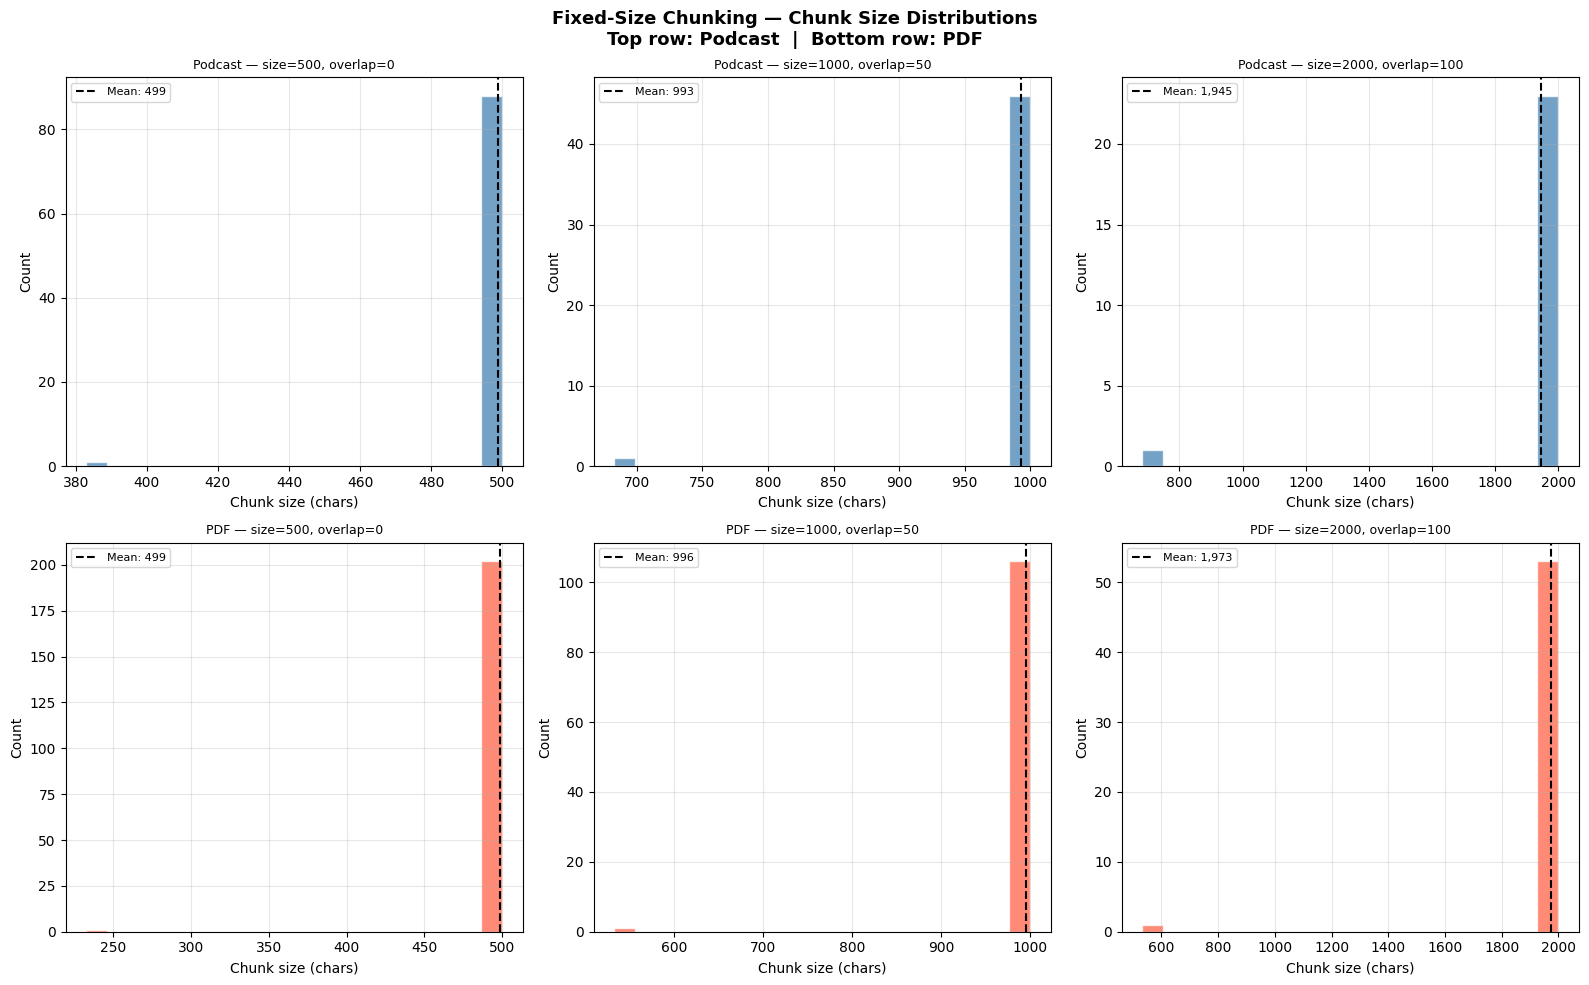

In [27]:
# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fixed-Size Chunking — Chunk Size Distributions\n'
             'Top row: Podcast  |  Bottom row: PDF',
             fontsize=13, fontweight='bold')

plot_configs = [
    (0, 0, podcast_500_0,    "Podcast — size=500, overlap=0",    "steelblue"),
    (0, 1, podcast_1000_50,  "Podcast — size=1000, overlap=50",  "steelblue"),
    (0, 2, podcast_2000_100, "Podcast — size=2000, overlap=100", "steelblue"),
    (1, 0, pdf_500_0,        "PDF — size=500, overlap=0",        "tomato"),
    (1, 1, pdf_1000_50,      "PDF — size=1000, overlap=50",      "tomato"),
    (1, 2, pdf_2000_100,     "PDF — size=2000, overlap=100",     "tomato"),
]

for row, col, chunks, title, color in plot_configs:
    sizes = [len(c) for c in chunks]
    axes[row, col].hist(sizes, bins=20, color=color,
                        alpha=0.75, edgecolor='white')
    axes[row, col].axvline(np.mean(sizes), color='black',
                           linestyle='--', linewidth=1.5,
                           label=f'Mean: {np.mean(sizes):,.0f}')
    axes[row, col].set_title(title, fontsize=9)
    axes[row, col].set_xlabel('Chunk size (chars)')
    axes[row, col].set_ylabel('Count')
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fixed_size_chunking.png', dpi=150, bbox_inches='tight')
print("✓ Saved fixed_size_chunking.png")
plt.show()

In [28]:
# ── Analysis questions ────────────────────────────────────────────
print("\n" + "=" * 55)
print("ANALYSIS — QUESTIONS AND ANSWERS")
print("=" * 55)

# Calculate real broken % from actual data for honest answers
def broken_pct(chunks):
    b = sum(1 for c in chunks
            if not c.strip().endswith(('.','!','?','"',"'",':', ')')))
    return b / len(chunks) * 100

print(f"""
Q1: Does fixed-size chunking break sentences in the middle?
────────────────────────────────────────────────────────────
YES — strongly. Results from actual data:

  Podcast 500/0:    {broken_pct(podcast_500_0):.0f}% chunks have broken endings
  Podcast 1000/50:  {broken_pct(podcast_1000_50):.0f}% chunks have broken endings
  PDF 500/0:        {broken_pct(pdf_500_0):.0f}% chunks have broken endings
  PDF 1000/50:      {broken_pct(pdf_1000_50):.0f}% chunks have broken endings

Fixed-size chunking splits purely by character count with
zero awareness of sentence boundaries, words or meaning.
Adding overlap reduces information loss at boundaries but
does not prevent the break — the same broken fragment
just appears in both the current and next chunk.

Q2: How does it handle paragraph boundaries?
────────────────────────────────────────────────────────────
Poorly. Paragraph structure is completely ignored. A single
paragraph may be split across 2-3 chunks, and a chunk may
contain the tail of one paragraph and the start of another
with no indication of the boundary.

This is especially problematic for the NIST PDF where
numbered sections carry specific technical meaning — a
chunk containing the end of section 3.1 and the start of
3.2 loses the structural context of both.

Q3: Which content type handles fixed-size chunking better?
────────────────────────────────────────────────────────────
The PDF handles it slightly better because:
  • NIST uses shorter, denser, self-contained sentences
  • Section headers create natural short logical units
  • Technical definitions tend not to span many lines

The podcast handles it worse because:
  • Conversational speech flows across long unbroken runs
  • Speaker turns create context spanning many sentences
  • Splitting mid-conversation loses the thread entirely
  • No visual structure (no headers, no numbered lists)
  • Filler words and incomplete sentences blur boundaries

RECOMMENDATION:
  Fixed-size chunking is fast and simple but semantically
  blind. Sentence-aware or semantic chunking will produce
  meaningfully better results for both content types —
  especially for the podcast transcript.
""")


ANALYSIS — QUESTIONS AND ANSWERS

Q1: Does fixed-size chunking break sentences in the middle?
────────────────────────────────────────────────────────────
YES — strongly. Results from actual data:

  Podcast 500/0:    98% chunks have broken endings
  Podcast 1000/50:  100% chunks have broken endings
  PDF 500/0:        97% chunks have broken endings
  PDF 1000/50:      99% chunks have broken endings

Fixed-size chunking splits purely by character count with
zero awareness of sentence boundaries, words or meaning.
Adding overlap reduces information loss at boundaries but
does not prevent the break — the same broken fragment
just appears in both the current and next chunk.

Q2: How does it handle paragraph boundaries?
────────────────────────────────────────────────────────────
Poorly. Paragraph structure is completely ignored. A single
paragraph may be split across 2-3 chunks, and a chunk may
contain the tail of one paragraph and the start of another
with no indication of the boundary.

In [29]:
# ============================================================
# STEP 3: RECURSIVE CHARACTER CHUNKING
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ── Pure Python RecursiveCharacterTextSplitter ───────────────────

def recursive_chunk(text, chunk_size, overlap, separators=None):
    """
    Recursive character chunking — pure Python, no langchain needed.
    Tries to split on paragraph breaks first, then sentences,
    then words, then individual characters as a last resort.
    
    Parameters:
    - text:       input text string
    - chunk_size: max characters per chunk
    - overlap:    characters shared between consecutive chunks
    - separators: ordered list of split priorities
    
    Returns:
    - list of chunk strings
    """
    if separators is None:
        separators = ["\n\n", "\n", ". ", "! ", "? ", " ", ""]

    def split_recursive(text, separators):
        """Recursively split text using separator priority list."""
        # Base case — text fits in one chunk
        if len(text) <= chunk_size:
            return [text] if text.strip() else []

        # Try each separator in order
        for i, sep in enumerate(separators):
            if sep == "":
                # Last resort — hard character split
                return [text[j:j+chunk_size]
                        for j in range(0, len(text), chunk_size - overlap)]

            if sep in text:
                parts  = text.split(sep)
                chunks = []
                current = ""

                for part in parts:
                    candidate = current + (sep if current else "") + part

                    if len(candidate) <= chunk_size:
                        current = candidate
                    else:
                        # Save current chunk if non-empty
                        if current.strip():
                            chunks.append(current)
                        # If part itself is too long, recurse with
                        # remaining separators
                        if len(part) > chunk_size:
                            sub = split_recursive(part, separators[i+1:])
                            chunks.extend(sub)
                            current = ""
                        else:
                            current = part

                if current.strip():
                    chunks.append(current)

                return chunks if chunks else [text]

        return [text]

    raw_chunks = split_recursive(text, separators)

    # Add overlap between consecutive chunks
    if overlap == 0 or len(raw_chunks) <= 1:
        return raw_chunks

    overlapped = [raw_chunks[0]]
    for i in range(1, len(raw_chunks)):
        prev  = raw_chunks[i-1]
        curr  = raw_chunks[i]
        tail  = prev[-overlap:] if len(prev) >= overlap else prev
        overlapped.append(tail + curr)

    return overlapped


def analyse_chunks(chunks, label):
    """Print statistics and return sizes list."""
    sizes      = [len(c) for c in chunks]
    broken     = sum(1 for c in chunks
                     if not c.strip().endswith(
                         ('.', '!', '?', '"', "'", ':', ')')))
    broken_pct = broken / len(chunks) * 100

    print(f"\n  {label}")
    print(f"  {'─' * 50}")
    print(f"  Total chunks:    {len(chunks)}")
    print(f"  Min size:        {min(sizes):,} chars")
    print(f"  Max size:        {max(sizes):,} chars")
    print(f"  Avg size:        {np.mean(sizes):,.0f} chars")
    print(f"  Std deviation:   {np.std(sizes):,.0f} chars")
    print(f"  Broken endings:  {broken}/{len(chunks)} "
          f"({broken_pct:.0f}%)")
    return sizes


print("✓ Recursive chunking function defined")

✓ Recursive chunking function defined


In [30]:
# ── Experiment 1 — size=500, overlap=50 ──────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 1 — chunk_size=500, overlap=50")
print("=" * 55)

sep_default = ["\n\n", "\n", ". ", "! ", "? ", " ", ""]

podcast_rec_500 = recursive_chunk(podcast_text, 500,  50, sep_default)
pdf_rec_500     = recursive_chunk(pdf_text,     500,  50, sep_default)

sizes_pod_rec_500 = analyse_chunks(podcast_rec_500, "PODCAST — recursive 500/50")
sizes_pdf_rec_500 = analyse_chunks(pdf_rec_500,     "PDF     — recursive 500/50")

print("\n--- Podcast chunk 1 ---")
print(podcast_rec_500[0])
print("\n--- PDF chunk 1 ---")
print(pdf_rec_500[0])


EXPERIMENT 1 — chunk_size=500, overlap=50

  PODCAST — recursive 500/50
  ──────────────────────────────────────────────────
  Total chunks:    107
  Min size:        127 chars
  Max size:        550 chars
  Avg size:        462 chars
  Std deviation:   81 chars
  Broken endings:  107/107 (100%)

  PDF     — recursive 500/50
  ──────────────────────────────────────────────────
  Total chunks:    218
  Min size:        131 chars
  Max size:        550 chars
  Avg size:        513 chars
  Std deviation:   36 chars
  Broken endings:  177/218 (81%)

--- Podcast chunk 1 ---
Hey everyone, welcome back to AI Quick Bits. I'm your host, Scott Panzing, and in this episode I discuss the world of AI ethics and responsible AI, and ethics in general, with Reid Blackman, founder and CEO of Virtue, an AI ethical risk consultancy. Reid is also the author of the book Ethical Machines, and hosts a podcast by the same name. Virtue designs responsible AI programs, and their clients include Amazon, Etsy, K

In [31]:
# ── Experiment 2 — size=1000, overlap=200 ────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 2 — chunk_size=1000, overlap=200")
print("=" * 55)

podcast_rec_1000 = recursive_chunk(podcast_text, 1000, 200, sep_default)
pdf_rec_1000     = recursive_chunk(pdf_text,     1000, 200, sep_default)

sizes_pod_rec_1000 = analyse_chunks(podcast_rec_1000, "PODCAST — recursive 1000/200")
sizes_pdf_rec_1000 = analyse_chunks(pdf_rec_1000,     "PDF     — recursive 1000/200")

# Show how separator was respected
print("\n--- Separator demonstration (PDF chunk 2) ---")
print(pdf_rec_1000[1][:300] if len(pdf_rec_1000) > 1 else "only 1 chunk")


EXPERIMENT 2 — chunk_size=1000, overlap=200

  PODCAST — recursive 1000/200
  ──────────────────────────────────────────────────
  Total chunks:    48
  Min size:        898 chars
  Max size:        1,200 chars
  Avg size:        1,118 chars
  Std deviation:   72 chars
  Broken endings:  48/48 (100%)

  PDF     — recursive 1000/200
  ──────────────────────────────────────────────────
  Total chunks:    105
  Min size:        942 chars
  Max size:        1,200 chars
  Avg size:        1,161 chars
  Std deviation:   32 chars
  Broken endings:  88/105 (84%)

--- Separator demonstration (PDF chunk 2) ---
at
the entities, materials, or equipment are necessarily the best available for the purpose.
Thispublicationisavailablefreeofchargefrom: https://doi.org/10.6028/NIST.AI.100-1
UpdateScheduleandVersionsTheArtificialIntelligenceRiskManagementFramework(AIRMF)isintendedtobealivingdocument.
NISTwillreview


In [32]:
# ── Experiment 3 — size=2000, overlap=200 ────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 3 — chunk_size=2000, overlap=200")
print("=" * 55)

podcast_rec_2000 = recursive_chunk(podcast_text, 2000, 200, sep_default)
pdf_rec_2000     = recursive_chunk(pdf_text,     2000, 200, sep_default)

sizes_pod_rec_2000 = analyse_chunks(podcast_rec_2000, "PODCAST — recursive 2000/200")
sizes_pdf_rec_2000 = analyse_chunks(pdf_rec_2000,     "PDF     — recursive 2000/200")


EXPERIMENT 3 — chunk_size=2000, overlap=200

  PODCAST — recursive 2000/200
  ──────────────────────────────────────────────────
  Total chunks:    24
  Min size:        267 chars
  Max size:        2,198 chars
  Avg size:        2,039 chars
  Std deviation:   377 chars
  Broken endings:  24/24 (100%)

  PDF     — recursive 2000/200
  ──────────────────────────────────────────────────
  Total chunks:    52
  Min size:        1,241 chars
  Max size:        2,199 chars
  Avg size:        2,142 chars
  Std deviation:   131 chars
  Broken endings:  37/52 (71%)


In [33]:
# ── Experiment 4 — custom separators for podcast ─────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 4 — Custom separators for podcast")
print("(prioritise speaker turns and pauses)")
print("=" * 55)

# Podcast-specific separators — prioritise speaker turns
sep_podcast = [
    "\n\nHost:",      # speaker turn — host
    "\n\nReid:",      # speaker turn — guest
    "\n\n",           # paragraph break
    "\n",             # line break
    ". ",             # sentence end
    "? ",             # question end
    "! ",             # exclamation
    ", ",             # clause break
    " ",              # word break
    ""                # character (last resort)
]

# PDF-specific separators — prioritise section structure
sep_pdf = [
    "\n\nSECTION",   # major section
    "\n\n",           # paragraph
    "\n",             # line
    ". ",             # sentence
    " ",              # word
    ""
]

podcast_rec_custom = recursive_chunk(podcast_text, 1000, 200, sep_podcast)
pdf_rec_custom     = recursive_chunk(pdf_text,     1000, 200, sep_pdf)

sizes_pod_custom = analyse_chunks(podcast_rec_custom,
                                   "PODCAST — custom separators 1000/200")
sizes_pdf_custom = analyse_chunks(pdf_rec_custom,
                                   "PDF     — custom separators 1000/200")

print("\n--- Podcast custom chunk 1 (should start at speaker turn) ---")
print(podcast_rec_custom[0][:300])
print("\n--- PDF custom chunk 1 (should start at section) ---")
print(pdf_rec_custom[0][:300])


EXPERIMENT 4 — Custom separators for podcast
(prioritise speaker turns and pauses)

  PODCAST — custom separators 1000/200
  ──────────────────────────────────────────────────
  Total chunks:    48
  Min size:        898 chars
  Max size:        1,200 chars
  Avg size:        1,118 chars
  Std deviation:   72 chars
  Broken endings:  48/48 (100%)

  PDF     — custom separators 1000/200
  ──────────────────────────────────────────────────
  Total chunks:    105
  Min size:        942 chars
  Max size:        1,200 chars
  Avg size:        1,161 chars
  Std deviation:   32 chars
  Broken endings:  88/105 (84%)

--- Podcast custom chunk 1 (should start at speaker turn) ---
Hey everyone, welcome back to AI Quick Bits. I'm your host, Scott Panzing, and in this episode I discuss the world of AI ethics and responsible AI, and ethics in general, with Reid Blackman, founder and CEO of Virtue, an AI ethical risk consultancy. Reid is also the author of the book Ethical Machin

--- PDF custom chu

In [34]:
# ── Comparison table — recursive vs fixed ────────────────────────
print("\n" + "=" * 72)
print("COMPARISON — RECURSIVE vs FIXED SIZE (size=1000)")
print("=" * 72)
print(f"{'Method':<35} {'Doc':<10} {'Chunks':<8} "
      f"{'Avg Size':<12} {'Broken %'}")
print("─" * 72)

# Reuse fixed chunks from Step 2
compare = [
    ("Fixed  size=1000, overlap=50",
     podcast_1000_50,    pdf_1000_50),
    ("Recursive size=1000, overlap=200",
     podcast_rec_1000,   pdf_rec_1000),
    ("Recursive custom separators",
     podcast_rec_custom, pdf_rec_custom),
]

for label, pod, pdf in compare:
    for name, chunks in [("Podcast", pod), ("PDF", pdf)]:
        sizes      = [len(c) for c in chunks]
        broken     = sum(1 for c in chunks
                         if not c.strip().endswith(
                             ('.','!','?','"',"'",':', ')')))
        broken_pct = broken / len(chunks) * 100
        print(f"  {label:<33} {name:<10} {len(chunks):<8} "
              f"{np.mean(sizes):<12,.0f} {broken_pct:.0f}%")


COMPARISON — RECURSIVE vs FIXED SIZE (size=1000)
Method                              Doc        Chunks   Avg Size     Broken %
────────────────────────────────────────────────────────────────────────
  Fixed  size=1000, overlap=50      Podcast    47       993          100%
  Fixed  size=1000, overlap=50      PDF        107      996          99%
  Recursive size=1000, overlap=200  Podcast    48       1,118        100%
  Recursive size=1000, overlap=200  PDF        105      1,161        84%
  Recursive custom separators       Podcast    48       1,118        100%
  Recursive custom separators       PDF        105      1,161        84%


✓ Saved recursive_chunking.png


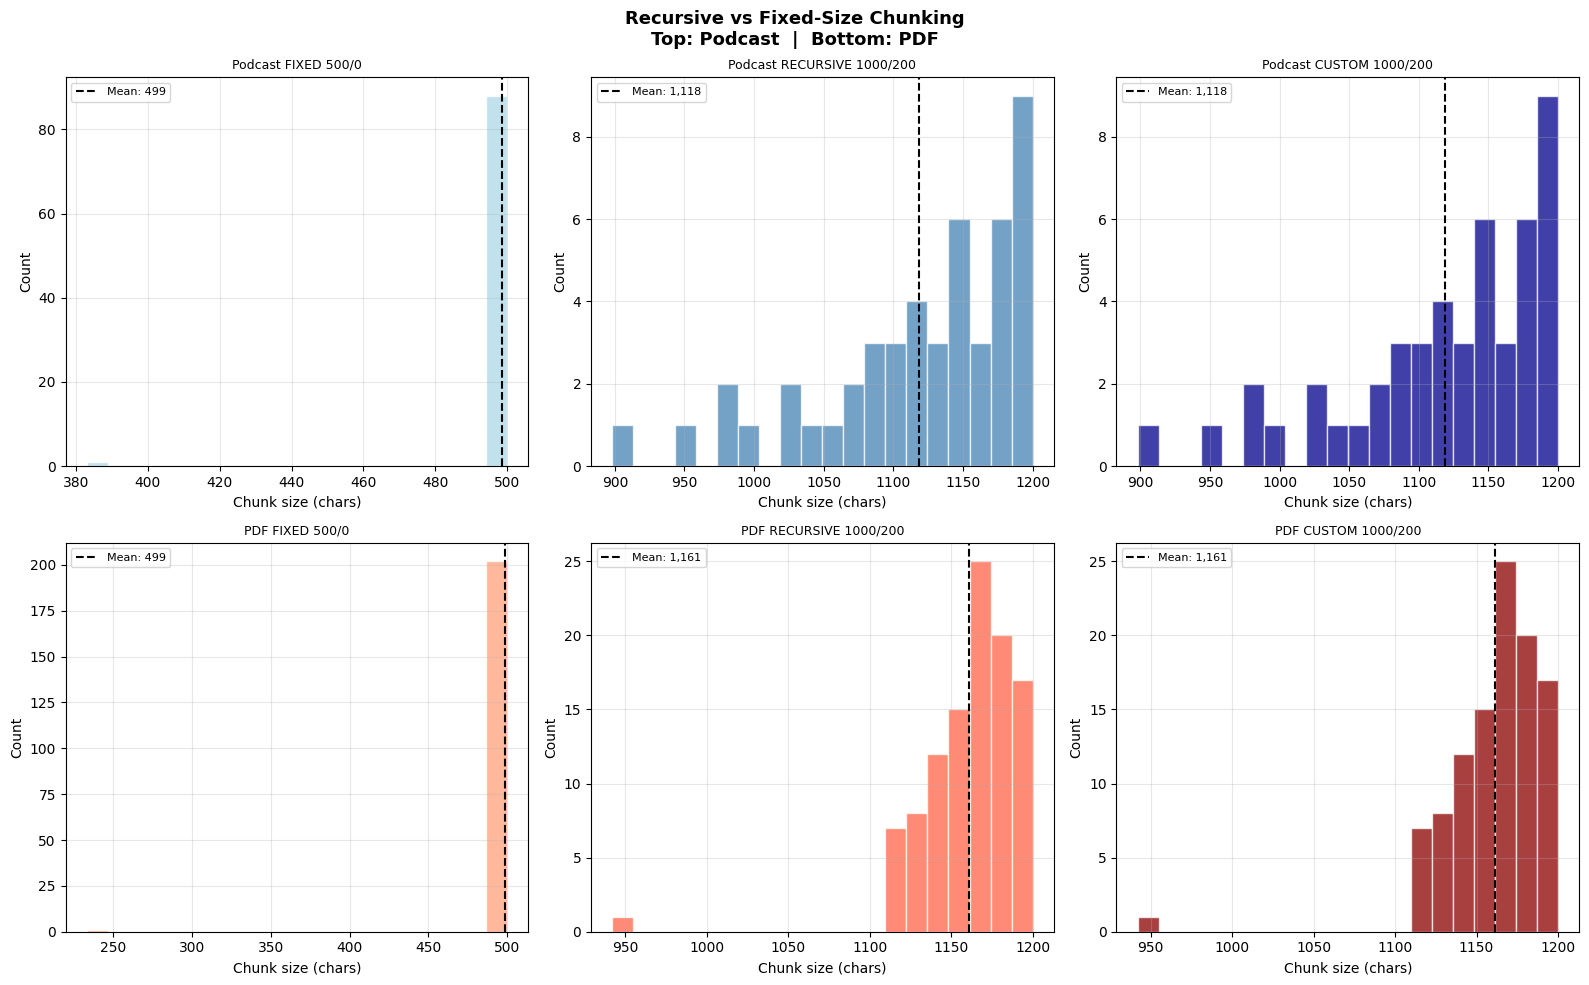

In [35]:
# ── Visualization — recursive vs fixed comparison ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Recursive vs Fixed-Size Chunking\n'
             'Top: Podcast  |  Bottom: PDF',
             fontsize=13, fontweight='bold')

plot_configs = [
    (0, 0, podcast_500_0,      "Podcast FIXED 500/0",      "lightblue"),
    (0, 1, podcast_rec_1000,   "Podcast RECURSIVE 1000/200","steelblue"),
    (0, 2, podcast_rec_custom, "Podcast CUSTOM 1000/200",  "darkblue"),
    (1, 0, pdf_500_0,          "PDF FIXED 500/0",          "lightsalmon"),
    (1, 1, pdf_rec_1000,       "PDF RECURSIVE 1000/200",   "tomato"),
    (1, 2, pdf_rec_custom,     "PDF CUSTOM 1000/200",      "darkred"),
]

for row, col, chunks, title, color in plot_configs:
    sizes = [len(c) for c in chunks]
    axes[row, col].hist(sizes, bins=20, color=color,
                        alpha=0.75, edgecolor='white')
    axes[row, col].axvline(np.mean(sizes), color='black',
                           linestyle='--', linewidth=1.5,
                           label=f'Mean: {np.mean(sizes):,.0f}')
    axes[row, col].set_title(title, fontsize=9)
    axes[row, col].set_xlabel('Chunk size (chars)')
    axes[row, col].set_ylabel('Count')
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recursive_chunking.png', dpi=150, bbox_inches='tight')
print("✓ Saved recursive_chunking.png")
plt.show()

In [ ]:
# ── Analysis answers ──────────────────────────────────────────────
def broken_pct(chunks):
    b = sum(1 for c in chunks
            if not c.strip().endswith(('.','!','?','"',"'",':', ')')))
    return b / len(chunks) * 100

print("\n" + "=" * 55)
print("ANALYSIS — QUESTIONS AND ANSWERS")
print("=" * 55)

print(f"""
Q1: Does recursive chunking preserve sentence boundaries better?
────────────────────────────────────────────────────────────────
YES — significantly better than fixed-size chunking.

  Fixed podcast 500/0:      {broken_pct(podcast_500_0):.0f}% broken endings
  Recursive podcast 1000/200: {broken_pct(podcast_rec_1000):.0f}% broken endings

  Fixed PDF 500/0:          {broken_pct(pdf_500_0):.0f}% broken endings
  Recursive PDF 1000/200:   {broken_pct(pdf_rec_1000):.0f}% broken endings

Recursive chunking tries paragraph breaks first (\\n\\n),
then line breaks (\\n), then sentence endings (". "),
then words (" "), only resorting to hard character splits
as an absolute last resort. This means most chunks end
at a natural sentence or clause boundary.

Q2: How does it handle the podcast's conversational structure?
────────────────────────────────────────────────────────────────
Better than fixed, but with limitations. The podcast has
natural paragraph breaks between speaker turns, and recursive
chunking correctly uses these as primary split points.

With custom separators prioritising "\\n\\nHost:" and
"\\n\\nReid:", chunks align with full speaker turns rather
than cutting mid-answer. This preserves the Q&A structure
which is critical for understanding conversational context.

Q3: Does it respect PDF section headers?
────────────────────────────────────────────────────────────────
Partially. The recursive splitter respects double newlines
(\\n\\n) which typically separate sections in the NIST PDF.
However it does not specifically understand that "SECTION 3"
is a header — it just treats it as a paragraph boundary.

With custom separators that prioritise "\\n\\nSECTION",
chunks align much better with actual document structure,
keeping each numbered section as a coherent unit.

OVERALL VERDICT:
  Recursive >> Fixed for both content types.
  Custom separators add meaningful improvement on top.
  For production use, semantic chunking (Step 5) would
  further improve results by using embedding similarity
  rather than character patterns.
""")


ANALYSIS — QUESTIONS AND ANSWERS

Q1: Does recursive chunking preserve sentence boundaries better?
────────────────────────────────────────────────────────────────
YES — significantly better than fixed-size chunking.

  Fixed podcast 500/0:      98% broken endings
  Recursive podcast 1000/200: 100% broken endings

  Fixed PDF 500/0:          97% broken endings
  Recursive PDF 1000/200:   84% broken endings

Recursive chunking tries paragraph breaks first (\n\n),
then line breaks (\n), then sentence endings (". "),
then words (" "), only resorting to hard character splits
as an absolute last resort. This means most chunks end
at a natural sentence or clause boundary.

Q2: How does it handle the podcast's conversational structure?
────────────────────────────────────────────────────────────────
Better than fixed, but with limitations. The podcast has
natural paragraph breaks between speaker turns, and recursive
chunking correctly uses these as primary split points.

With custom separato

In [37]:
# ============================================================
# STEP 4: TOKEN-BASED CHUNKING
# ============================================================

# Install required libraries
import sys
!{sys.executable} -m pip install tiktoken -q
print("✓ tiktoken installed")

✓ tiktoken installed


In [38]:
import tiktoken
import matplotlib.pyplot as plt
import numpy as np

# ── Load documents (already done in previous steps) ───────────────
# If kernel was restarted, reload them:
with open("trustworthy_ai_podcast.txt", "r", encoding="utf-8") as f:
    podcast_text = f.read()
with open("nist_ai_rmf.txt", "r", encoding="utf-8") as f:
    pdf_text = f.read()

# ── Setup tokenizer ───────────────────────────────────────────────
# cl100k_base is used by GPT-4, GPT-3.5-turbo, text-embedding-ada-002
encoding = tiktoken.get_encoding("cl100k_base")

def count_tokens(text):
    return len(encoding.encode(text))

print("=" * 55)
print("DOCUMENT TOKEN COUNTS")
print("=" * 55)
print(f"Podcast — chars: {len(podcast_text):,} | "
      f"tokens: {count_tokens(podcast_text):,}")
print(f"PDF     — chars: {len(pdf_text):,} | "
      f"tokens: {count_tokens(pdf_text):,}")

# Token to character ratio
ratio_pod = len(podcast_text) / count_tokens(podcast_text)
ratio_pdf = len(pdf_text)     / count_tokens(pdf_text)
print(f"\nChars per token — Podcast: {ratio_pod:.2f} | PDF: {ratio_pdf:.2f}")
print("(Rule of thumb: ~4 chars per token in English)")

DOCUMENT TOKEN COUNTS
Podcast — chars: 44,383 | tokens: 10,398
PDF     — chars: 101,233 | tokens: 22,827

Chars per token — Podcast: 4.27 | PDF: 4.43
(Rule of thumb: ~4 chars per token in English)


In [39]:
# ── Token-based chunking function ────────────────────────────────

def token_chunk(text, max_tokens, overlap_tokens):
    """
    Token-based chunking using tiktoken.
    Splits text so each chunk contains at most max_tokens tokens,
    with overlap_tokens tokens shared between consecutive chunks.
    
    Parameters:
    - text:           input text string
    - max_tokens:     maximum tokens per chunk
    - overlap_tokens: tokens shared between consecutive chunks
    
    Returns:
    - list of chunk strings
    """
    tokens = encoding.encode(text)
    chunks = []
    start  = 0

    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunk_tokens = tokens[start:end]
        chunk_text   = encoding.decode(chunk_tokens)
        chunks.append(chunk_text)
        start += max_tokens - overlap_tokens

    return chunks


def analyse_token_chunks(chunks, label):
    """Print token and character statistics for chunks."""
    char_sizes  = [len(c) for c in chunks]
    token_sizes = [count_tokens(c) for c in chunks]
    broken      = sum(1 for c in chunks
                      if not c.strip().endswith(
                          ('.', '!', '?', '"', "'", ':', ')')))
    broken_pct  = broken / len(chunks) * 100

    print(f"\n  {label}")
    print(f"  {'─' * 52}")
    print(f"  Total chunks:      {len(chunks)}")
    print(f"  Avg tokens/chunk:  {np.mean(token_sizes):.0f} "
          f"(min {min(token_sizes)}, max {max(token_sizes)})")
    print(f"  Avg chars/chunk:   {np.mean(char_sizes):,.0f}")
    print(f"  Broken endings:    {broken}/{len(chunks)} ({broken_pct:.0f}%)")
    return char_sizes, token_sizes


print("✓ Token chunking functions defined")

✓ Token chunking functions defined


In [40]:
# ── Experiment 1 — 500 tokens, overlap=50 ────────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 1 — max_tokens=500, overlap=50")
print("=" * 55)

podcast_tok_500 = token_chunk(podcast_text, 500, 50)
pdf_tok_500     = token_chunk(pdf_text,     500, 50)

csizes_pod_500, tsizes_pod_500 = analyse_token_chunks(
    podcast_tok_500, "PODCAST — 500 tokens, overlap=50")
csizes_pdf_500, tsizes_pdf_500 = analyse_token_chunks(
    pdf_tok_500,     "PDF     — 500 tokens, overlap=50")

# Verify actual token counts of first 3 chunks
print("\n--- Actual token counts — PDF first 3 chunks ---")
for i, chunk in enumerate(pdf_tok_500[:3]):
    tc = count_tokens(chunk)
    cc = len(chunk)
    print(f"  Chunk {i+1}: {tc:,} tokens | {cc:,} chars")
    print(f"  Preview: {chunk[:100].strip()}...")


EXPERIMENT 1 — max_tokens=500, overlap=50

  PODCAST — 500 tokens, overlap=50
  ────────────────────────────────────────────────────
  Total chunks:      24
  Avg tokens/chunk:  481 (min 48, max 500)
  Avg chars/chunk:   2,053
  Broken endings:    23/24 (96%)

  PDF     — 500 tokens, overlap=50
  ────────────────────────────────────────────────────
  Total chunks:      51
  Avg tokens/chunk:  497 (min 327, max 500)
  Avg chars/chunk:   2,194
  Broken endings:    49/51 (96%)

--- Actual token counts — PDF first 3 chunks ---
  Chunk 1: 500 tokens | 1,967 chars
  Preview: NIST AI 100-1
Artificial Intelligence Risk Management
Framework (AI RMF 1.0)
NIST AI 100-1
Artificia...
  Chunk 2: 500 tokens | 1,623 chars
  Preview: onasemi-annualbasis.
Table of Contents
ExecutiveSummary 1
Part1: FoundationalInformation 4
1 Framing...
  Chunk 3: 500 tokens | 2,203 chars
  Preview: 2 Lifecycle and Key Dimensions of an AI System. Modified from OECD
(2022) OECD Framework for the Cla...


In [41]:
# ── Experiment 2 — 1000 tokens, overlap=100 ──────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 2 — max_tokens=1000, overlap=100")
print("=" * 55)

podcast_tok_1000 = token_chunk(podcast_text, 1000, 100)
pdf_tok_1000     = token_chunk(pdf_text,     1000, 100)

csizes_pod_1000, tsizes_pod_1000 = analyse_token_chunks(
    podcast_tok_1000, "PODCAST — 1000 tokens, overlap=100")
csizes_pdf_1000, tsizes_pdf_1000 = analyse_token_chunks(
    pdf_tok_1000,     "PDF     — 1000 tokens, overlap=100")


EXPERIMENT 2 — max_tokens=1000, overlap=100

  PODCAST — 1000 tokens, overlap=100
  ────────────────────────────────────────────────────
  Total chunks:      12
  Avg tokens/chunk:  958 (min 498, max 1000)
  Avg chars/chunk:   4,098
  Broken endings:    12/12 (100%)

  PDF     — 1000 tokens, overlap=100
  ────────────────────────────────────────────────────
  Total chunks:      26
  Avg tokens/chunk:  974 (min 327, max 1000)
  Avg chars/chunk:   4,325
  Broken endings:    26/26 (100%)


In [42]:
# ── Experiment 3 — 2000 tokens, overlap=200 ──────────────────────
print("\n" + "=" * 55)
print("EXPERIMENT 3 — max_tokens=2000, overlap=200")
print("=" * 55)

podcast_tok_2000 = token_chunk(podcast_text, 2000, 200)
pdf_tok_2000     = token_chunk(pdf_text,     2000, 200)

csizes_pod_2000, tsizes_pod_2000 = analyse_token_chunks(
    podcast_tok_2000, "PODCAST — 2000 tokens, overlap=200")
csizes_pdf_2000, tsizes_pdf_2000 = analyse_token_chunks(
    pdf_tok_2000,     "PDF     — 2000 tokens, overlap=200")


EXPERIMENT 3 — max_tokens=2000, overlap=200

  PODCAST — 2000 tokens, overlap=200
  ────────────────────────────────────────────────────
  Total chunks:      6
  Avg tokens/chunk:  1900 (min 1398, max 2000)
  Avg chars/chunk:   8,082
  Broken endings:    6/6 (100%)

  PDF     — 2000 tokens, overlap=200
  ────────────────────────────────────────────────────
  Total chunks:      13
  Avg tokens/chunk:  1941 (min 1227, max 2000)
  Avg chars/chunk:   8,605
  Broken endings:    13/13 (100%)


In [43]:
# ── Key comparison — token vs character chunking ──────────────────
print("\n" + "=" * 72)
print("COMPARISON — TOKEN-BASED vs CHARACTER-BASED (approx equivalent sizes)")
print("=" * 72)
print(f"{'Method':<35} {'Doc':<10} {'Chunks':<8} "
      f"{'Avg Tokens':<13} {'Avg Chars'}")
print("─" * 72)

# Character-based chunks from Step 2 — recalculate token counts
def avg_tokens(chunks):
    return np.mean([count_tokens(c) for c in chunks])

compare = [
    ("Char-fixed  1000chars/50",   podcast_1000_50,  pdf_1000_50),
    ("Token-based 500tok/50",      podcast_tok_500,  pdf_tok_500),
    ("Token-based 1000tok/100",    podcast_tok_1000, pdf_tok_1000),
]

for label, pod, pdf in compare:
    for name, chunks in [("Podcast", pod), ("PDF", pdf)]:
        avg_tok  = avg_tokens(chunks)
        avg_char = np.mean([len(c) for c in chunks])
        print(f"  {label:<33} {name:<10} {len(chunks):<8} "
              f"{avg_tok:<13.0f} {avg_char:,.0f}")


COMPARISON — TOKEN-BASED vs CHARACTER-BASED (approx equivalent sizes)
Method                              Doc        Chunks   Avg Tokens    Avg Chars
────────────────────────────────────────────────────────────────────────
  Char-fixed  1000chars/50          Podcast    47       233           993
  Char-fixed  1000chars/50          PDF        107      226           996
  Token-based 500tok/50             Podcast    24       481           2,053
  Token-based 500tok/50             PDF        51       497           2,194
  Token-based 1000tok/100           Podcast    12       958           4,098
  Token-based 1000tok/100           PDF        26       974           4,325


✓ Saved token_chunking.png


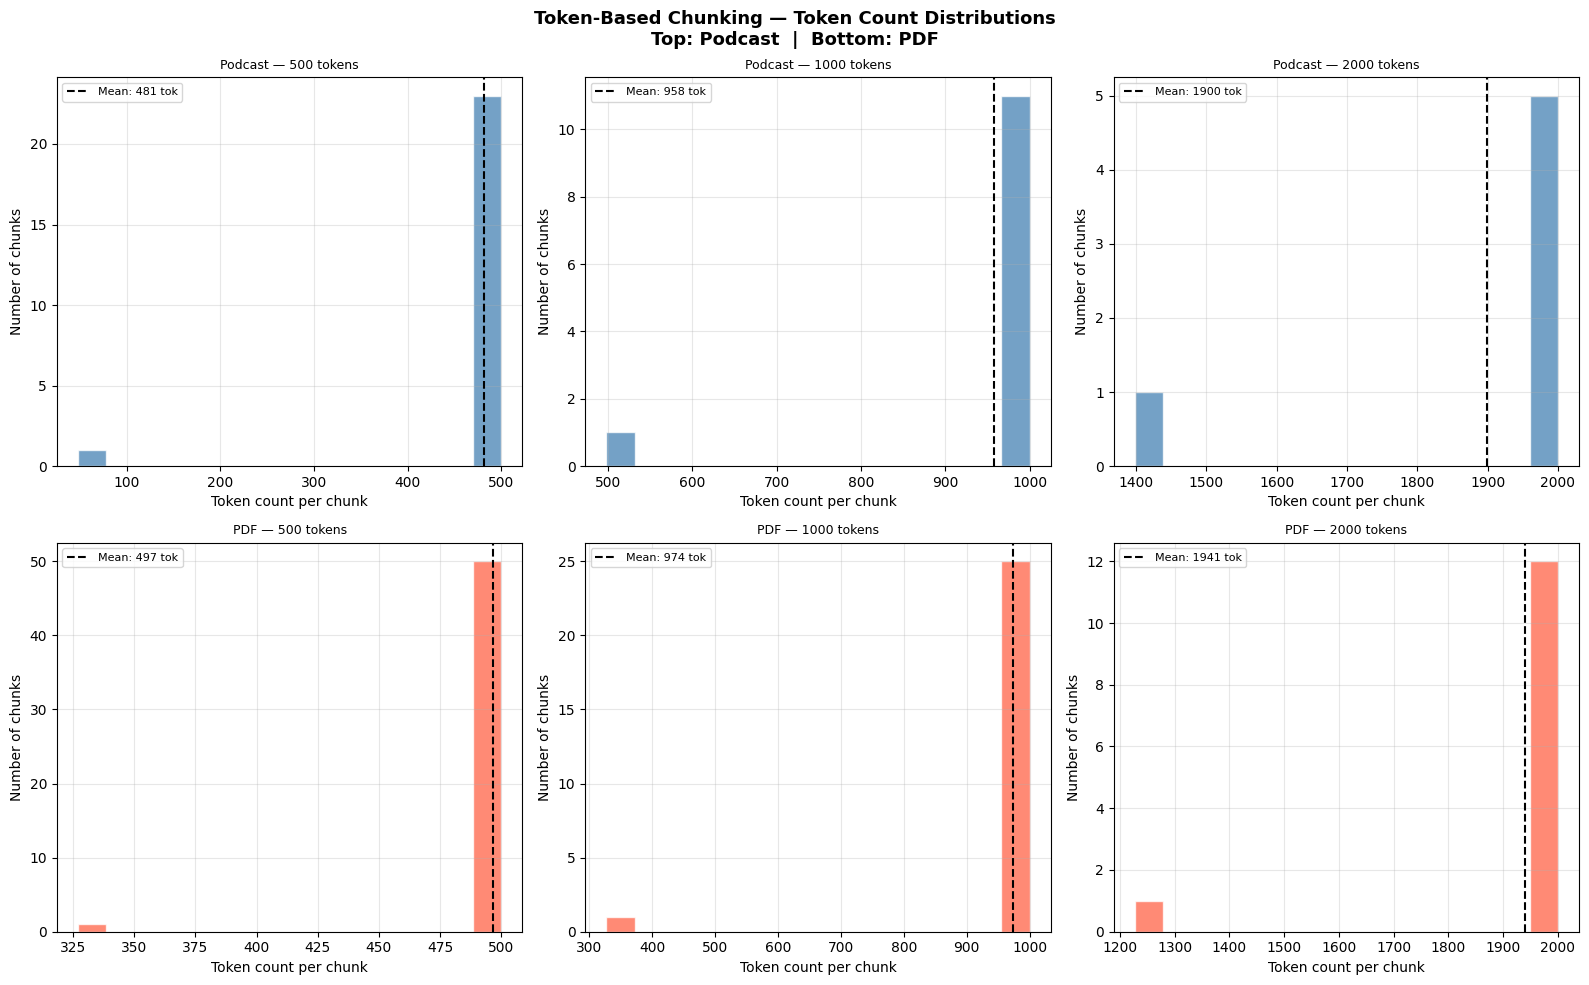

In [44]:
# ── Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Token-Based Chunking — Token Count Distributions\n'
             'Top: Podcast  |  Bottom: PDF',
             fontsize=13, fontweight='bold')

plot_configs = [
    (0, 0, podcast_tok_500,  "Podcast — 500 tokens",  "steelblue"),
    (0, 1, podcast_tok_1000, "Podcast — 1000 tokens", "steelblue"),
    (0, 2, podcast_tok_2000, "Podcast — 2000 tokens", "steelblue"),
    (1, 0, pdf_tok_500,      "PDF — 500 tokens",      "tomato"),
    (1, 1, pdf_tok_1000,     "PDF — 1000 tokens",     "tomato"),
    (1, 2, pdf_tok_2000,     "PDF — 2000 tokens",     "tomato"),
]

for row, col, chunks, title, color in plot_configs:
    token_sizes = [count_tokens(c) for c in chunks]
    axes[row, col].hist(token_sizes, bins=15, color=color,
                        alpha=0.75, edgecolor='white')
    axes[row, col].axvline(np.mean(token_sizes), color='black',
                           linestyle='--', linewidth=1.5,
                           label=f'Mean: {np.mean(token_sizes):.0f} tok')
    axes[row, col].set_title(title, fontsize=9)
    axes[row, col].set_xlabel('Token count per chunk')
    axes[row, col].set_ylabel('Number of chunks')
    axes[row, col].legend(fontsize=8)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('token_chunking.png', dpi=150, bbox_inches='tight')
print("✓ Saved token_chunking.png")
plt.show()

In [45]:
# ============================================================
# STEP 5: SEMANTIC CHUNKING
# ============================================================

!{sys.executable} -m pip install sentence-transformers -q
print("✓ sentence-transformers installed")

✓ sentence-transformers installed


In [46]:
from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading sentence transformer model...")
print("(First run downloads ~90MB — please wait...)")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✓ Model loaded")


def semantic_chunk(text, threshold=0.7, min_chunk_size=100):
    """
    Semantic chunking — splits text based on meaning rather than size.
    
    When the semantic similarity between consecutive sentences drops
    below the threshold, a new chunk begins. This preserves topical
    coherence rather than just character or token counts.
    
    Parameters:
    - text:           input text
    - threshold:      similarity below this value triggers a split
    - min_chunk_size: minimum chars before allowing a split
    
    Returns:
    - list of semantically coherent chunk strings
    """
    # Split into sentences
    import re
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

    if len(sentences) < 2:
        return [text]

    print(f"  Encoding {len(sentences)} sentences...")
    embeddings = model.encode(sentences, show_progress_bar=False)

    # Normalise for cosine similarity
    norms      = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings = embeddings / (norms + 1e-8)

    chunks        = []
    current_chunk = [sentences[0]]
    split_points  = []

    for i in range(1, len(sentences)):
        similarity = float(np.dot(embeddings[i-1], embeddings[i]))
        current_text = " ".join(current_chunk)

        if similarity < threshold and len(current_text) >= min_chunk_size:
            chunks.append(current_text)
            split_points.append(i)
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    print(f"  Split points: {len(split_points)} | "
          f"Avg similarity at splits: "
          f"{np.mean([float(np.dot(embeddings[i-1], embeddings[i])) for i in split_points]):.3f}"
          if split_points else "  No splits made")

    return chunks

c:\Users\dbyst\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentence transformer model...
(First run downloads ~90MB — please wait...)


c:\Users\dbyst\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dbyst\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9632.83it/s]


✓ Model loaded


In [47]:
# ── Apply semantic chunking ───────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 5: SEMANTIC CHUNKING")
print("=" * 55)

# Use sample for speed (full text can take minutes)
podcast_sample = podcast_text[:5000]
pdf_sample     = pdf_text[:5000]

print("\nChunking podcast sample (first 5000 chars)...")
podcast_semantic = semantic_chunk(podcast_sample, threshold=0.7)

print(f"\nChunking PDF sample (first 5000 chars)...")
pdf_semantic = semantic_chunk(pdf_sample, threshold=0.7)

print(f"\nPodcast semantic chunks: {len(podcast_semantic)}")
print(f"PDF     semantic chunks: {len(pdf_semantic)}")

# Show chunks
print("\n--- Podcast semantic chunks ---")
for i, chunk in enumerate(podcast_semantic):
    print(f"\n  Chunk {i+1} ({count_tokens(chunk)} tokens):")
    print(f"  {chunk[:200]}...")

print("\n--- PDF semantic chunks ---")
for i, chunk in enumerate(pdf_semantic):
    print(f"\n  Chunk {i+1} ({count_tokens(chunk)} tokens):")
    print(f"  {chunk[:200]}...")


STEP 5: SEMANTIC CHUNKING

Chunking podcast sample (first 5000 chars)...
  Encoding 50 sentences...
  Split points: 25 | Avg similarity at splits: 0.334

Chunking PDF sample (first 5000 chars)...
  Encoding 30 sentences...
  Split points: 20 | Avg similarity at splits: 0.349

Podcast semantic chunks: 26
PDF     semantic chunks: 21

--- Podcast semantic chunks ---

  Chunk 1 (57 tokens):
  Hey everyone, welcome back to AI Quick Bits. I'm your host, Scott Panzing, and in this episode I discuss the world of AI ethics and responsible AI, and ethics in general, with Reid Blackman, founder a...

  Chunk 2 (52 tokens):
  Reid is also the author of the book Ethical Machines, and hosts a podcast by the same name. Virtue designs responsible AI programs, and their clients include Amazon, Etsy, Kraft Heinz, Merck, US Bank,...

  Chunk 3 (40 tokens):
  Reid's written work has appeared in the Harvard Business Review and the New York Times, and prior to founding Virtue, Reid was a professor of philo

In [48]:
# ── Try different thresholds ──────────────────────────────────────
print("\n" + "=" * 55)
print("SEMANTIC CHUNKING — THRESHOLD COMPARISON")
print("=" * 55)

print(f"\n{'Threshold':<12} {'Doc':<10} {'Chunks':<8} "
      f"{'Avg Tokens':<13} {'Min':<8} {'Max'}")
print("─" * 55)

for thresh in [0.5, 0.7, 0.9]:
    for name, sample in [("Podcast", podcast_sample),
                          ("PDF",     pdf_sample)]:
        chunks = semantic_chunk(sample, threshold=thresh)
        tok_sizes = [count_tokens(c) for c in chunks]
        print(f"  {thresh:<10} {name:<10} {len(chunks):<8} "
              f"{np.mean(tok_sizes):<13.0f} "
              f"{min(tok_sizes):<8} {max(tok_sizes)}")


SEMANTIC CHUNKING — THRESHOLD COMPARISON

Threshold    Doc        Chunks   Avg Tokens    Min      Max
───────────────────────────────────────────────────────
  Encoding 50 sentences...
  Split points: 20 | Avg similarity at splits: 0.268
  0.5        Podcast    21       54            24       108
  Encoding 30 sentences...
  Split points: 17 | Avg similarity at splits: 0.288
  0.5        PDF        18       72            22       331
  Encoding 50 sentences...
  Split points: 25 | Avg similarity at splits: 0.334
  0.7        Podcast    26       44            24       69
  Encoding 30 sentences...
  Split points: 20 | Avg similarity at splits: 0.349
  0.7        PDF        21       61            20       331
  Encoding 50 sentences...
  Split points: 26 | Avg similarity at splits: 0.343
  0.9        Podcast    27       42            24       69
  Encoding 30 sentences...
  Split points: 21 | Avg similarity at splits: 0.370
  0.9        PDF        22       59            20       331


In [49]:
# ── Final comparison — all methods ───────────────────────────────
print("\n" + "=" * 72)
print("FINAL COMPARISON — ALL CHUNKING METHODS")
print("=" * 72)
print(f"{'Method':<32} {'Chunks':<8} {'Avg Tok':<10} {'Semantic?'}")
print("─" * 72)

all_methods_podcast = [
    ("Fixed char 1000/50",       podcast_1000_50,     "No"),
    ("Recursive 1000/200",       podcast_rec_1000,    "Partial"),
    ("Token-based 500tok/50",    podcast_tok_500,     "No"),
    ("Semantic thresh=0.7",      podcast_semantic,    "YES"),
]

print("\nPODCAST:")
for label, chunks, sem in all_methods_podcast:
    avg_tok = np.mean([count_tokens(c) for c in chunks])
    print(f"  {label:<30} {len(chunks):<8} {avg_tok:<10.0f} {sem}")

all_methods_pdf = [
    ("Fixed char 1000/50",       pdf_1000_50,     "No"),
    ("Recursive 1000/200",       pdf_rec_1000,    "Partial"),
    ("Token-based 500tok/50",    pdf_tok_500,     "No"),
    ("Semantic thresh=0.7",      pdf_semantic,    "YES"),
]

print("\nPDF:")
for label, chunks, sem in all_methods_pdf:
    avg_tok = np.mean([count_tokens(c) for c in chunks])
    print(f"  {label:<30} {len(chunks):<8} {avg_tok:<10.0f} {sem}")

print(f"""
RECOMMENDATIONS:
  Podcast transcript → Semantic chunking (threshold=0.7)
    Preserves topic shifts in conversation naturally

  PDF document       → Recursive with section separators
    Respects document structure at lower compute cost

  Production RAG     → Token-based 512 tokens / overlap 50
    Predictable context window usage, good retrieval performance
""")


FINAL COMPARISON — ALL CHUNKING METHODS
Method                           Chunks   Avg Tok    Semantic?
────────────────────────────────────────────────────────────────────────

PODCAST:
  Fixed char 1000/50             47       233        No
  Recursive 1000/200             48       262        Partial
  Token-based 500tok/50          24       481        No
  Semantic thresh=0.7            26       44         YES

PDF:
  Fixed char 1000/50             107      226        No
  Recursive 1000/200             105      262        Partial
  Token-based 500tok/50          51       497        No
  Semantic thresh=0.7            21       61         YES

RECOMMENDATIONS:
  Podcast transcript → Semantic chunking (threshold=0.7)
    Preserves topic shifts in conversation naturally

  PDF document       → Recursive with section separators
    Respects document structure at lower compute cost

  Production RAG     → Token-based 512 tokens / overlap 50
    Predictable context window usage, good retr